# Fruit Quality Classification
### Quality Grading (`good`, `medium`, `bad`) Benchmark for Selected Fruit
This study evaluates five computer vision architectures on fruit quality assessment:
- Custom CNN
- MobileNetV3-Large
- YOLO26 Classifier
- EfficientNet-B0
- ResNet-50

**Target Quality Classes:** `good`, `medium`, `bad`

**Pipeline Outline:**
1. Environment Setup and Reproducibility
2. Fruit Category Selection and Quality Scan
3. Stratified Partitioning (80:20 Train:Test Split)
4. Quality-Preserving Data Augmentation
5. Training and Evaluation Infrastructure
6. Architectural Evaluation (Models 1 through 5)
7. Final Performance Comparison
8. Export Outputs


## 1. Environment Setup and Reproducibility


In [ ]:
# Dependencies installation
!pip install -q ultralytics scikit-learn seaborn matplotlib pandas torchvision torch optuna tqdm

import os
import sys
import math
import random
import shutil
import time
import gc
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, f1_score
from sklearn.preprocessing import label_binarize

from ultralytics import YOLO

# Plot styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

# Execution environment detection
IN_COLAB = 'google.colab' in sys.modules
IN_KAGGLE = os.path.exists('/kaggle') or 'KAGGLE_KERNEL_RUN_TYPE' in os.environ
ENV_NAME = "Google Colab" if IN_COLAB else ("Kaggle" if IN_KAGGLE else "Local Machine")

print(f"Environment: {ENV_NAME}")
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device Name: {torch.cuda.get_device_name(0)}")
    device = torch.device("cuda:0")
    torch.backends.cudnn.benchmark = True
else:
    print("Warning: CUDA is unavailable. Running on CPU.")
    device = torch.device("cpu")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 7.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Environment: Google Colab
PyTorch Version: 2.11.0+cu128
CUDA Available: True
Device Name: Tesla T4


In [ ]:
# Seed configuration for reproducibility
SEED = 42

def seed_everything(seed=42):
    """Seed Python, NumPy, and PyTorch for deterministic execution."""
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

seed_everything(SEED)
print(f"Random seed locked: {SEED}")


Random seed locked: 42


In [ ]:
# Output directory initialization
OUTPUT_QUALITY_DIR = Path("outputs_quality")
MODELS_Q_DIR = OUTPUT_QUALITY_DIR / "models"
PLOTS_Q_DIR = OUTPUT_QUALITY_DIR / "plots"
REPORTS_Q_DIR = OUTPUT_QUALITY_DIR / "reports"

for p in [OUTPUT_QUALITY_DIR, MODELS_Q_DIR, PLOTS_Q_DIR, REPORTS_Q_DIR]:
    p.mkdir(parents=True, exist_ok=True)


### Dataset Download & Extract


In [ ]:
!python -m pip install --upgrade gdown -q
!gdown "https://drive.google.com/file/d/1RNFxIXg9lvxGuI-LwA6vh_ZsMnwrB_i8/view?usp=drive_link" -q
!mkdir -p original_dataset && cd "original_dataset" && tar -xf /content/fruit_dataset.tar


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.8/50.8 kB 3.2 MB/s eta 0:00:00


## 2. Fruit Selection and Targeted Scanning
Isolating the selected fruit category for quality grading.


In [ ]:
#@title Select Fruit for Quality Classification { run: "auto" }
SELECTED_FRUIT = "dragonfruit" #@param ["banana", "dragonfruit", "jackfruit", "lemon", "mango", "pineapple", "star_fruit", "custard_apple", "guava", "jujube", "lychee", "papaya", "sapodilla"] {type:"string"}

QUALITY_CLASSES = ['good', 'medium', 'bad']
VALID_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

def locate_quality_dataset_dir():
    candidates = [
        Path("original_dataset"),
        Path("/content/original_dataset"),
        Path("/kaggle/working/original_dataset")
    ]
    if Path("/kaggle/input").exists():
        for p in Path("/kaggle/input").rglob("original_dataset"):
            if p.is_dir():
                candidates.insert(0, p)
        for p in Path("/kaggle/input").glob("*"):
            if p.is_dir() and (p / SELECTED_FRUIT).exists():
                candidates.insert(0, p)

    for c in candidates:
        if c.exists() and (c / SELECTED_FRUIT).exists():
            return c
    return Path("original_dataset")

ORIGINAL_DATASET_DIR = locate_quality_dataset_dir()
print(f"Target fruit: {SELECTED_FRUIT.upper()}")


Target fruit: DRAGONFRUIT


In [ ]:
def scan_fruit_quality(base_dir: Path, fruit_name: str):
    fruit_dir = base_dir / fruit_name
    if not fruit_dir.exists():
        raise FileNotFoundError(f"Directory '{fruit_dir}' not found.")

    records = []
    for quality in QUALITY_CLASSES:
        q_dir = fruit_dir / quality
        if q_dir.exists():
            imgs = [f for f in q_dir.iterdir() if f.suffix.lower() in VALID_EXTENSIONS and f.is_file()]
            for img in imgs:
                records.append({
                    "fruit": fruit_name,
                    "quality": quality,
                    "file_name": img.name,
                    "path": str(img)
                })

    return pd.DataFrame(records)

df_quality = scan_fruit_quality(ORIGINAL_DATASET_DIR, SELECTED_FRUIT)
print(f"Total quality samples for '{SELECTED_FRUIT}': {len(df_quality)}")
df_quality.head()


Total quality samples for 'dragonfruit': 1667


,fruit,quality,file_name,path
0,dragonfruit,good,dragonfruit_g_1_487.jpg,original_dataset/dragonfruit/good/dragonfruit_...
1,dragonfruit,good,dragonfruit_g_1_141.jpg,original_dataset/dragonfruit/good/dragonfruit_...
2,dragonfruit,good,dragonfruit_g_1_118.jpg,original_dataset/dragonfruit/good/dragonfruit_...
3,dragonfruit,good,dragonfruit_g_1_106.jpg,original_dataset/dragonfruit/good/dragonfruit_...
4,dragonfruit,good,dragonfruit_g_1_553.jpg,original_dataset/dragonfruit/good/dragonfruit_...


,count
quality,
bad,579
good,560
medium,528


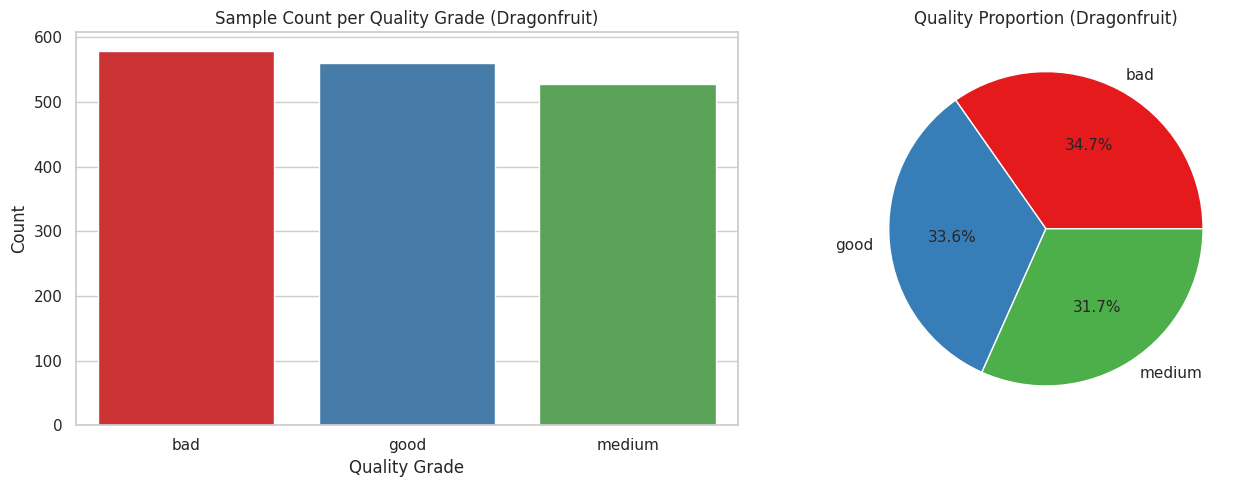

In [ ]:
# Quality distribution visualization
if not df_quality.empty:
    quality_counts = df_quality['quality'].value_counts()
    display(quality_counts)
    quality_counts.to_csv(REPORTS_Q_DIR / f"{SELECTED_FRUIT}_quality_distribution.csv")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.barplot(x=quality_counts.index, y=quality_counts.values, hue=quality_counts.index, palette="Set1", legend=False, ax=axes[0])
    axes[0].set_title(f"Sample Count per Quality Grade ({SELECTED_FRUIT.capitalize()})")
    axes[0].set_xlabel("Quality Grade")
    axes[0].set_ylabel("Count")

    axes[1].pie(quality_counts.values, labels=quality_counts.index, autopct='%1.1f%%', colors=sns.color_palette("Set1"))
    axes[1].set_title(f"Quality Proportion ({SELECTED_FRUIT.capitalize()})")
    plt.tight_layout()
    plt.savefig(PLOTS_Q_DIR / f"{SELECTED_FRUIT}_distribution.png", dpi=300)
    plt.show()


## 3. Stratified Partitioning (80:20 Train:Test Split)
Stratified splitting across the three quality classes (`good`, `medium`, `bad`) maintaining a 80:20 train:test distribution (80% Train, 20% Test).


In [ ]:
TARGET_QUALITY_DIR = Path("data_quality")

def prepare_stratified_quality_split(df: pd.DataFrame, target_base: Path, train_ratio=0.80, test_ratio=0.20):
    assert math.isclose(train_ratio + test_ratio, 1.0), "Split ratios must sum to 1.0"

    if target_base.exists():
        shutil.rmtree(target_base)

    for split in ['train', 'test']:
        for q in QUALITY_CLASSES:
            (target_base / split / q).mkdir(parents=True, exist_ok=True)

    train_df, test_df = train_test_split(
        df,
        test_size=test_ratio,
        stratify=df['quality'],
        random_state=SEED
    )

    splits = {'train': train_df, 'test': test_df}

    print(f"Quality partitions for '{SELECTED_FRUIT}' (80:20 Train:Test Split):")
    print(f"  Train: {len(train_df)} ({len(train_df)/len(df)*100:.1f}%)")
    print(f"  Test:  {len(test_df)} ({len(test_df)/len(df)*100:.1f}%)")

    copy_records = []
    for split_name, split_data in splits.items():
        pbar = tqdm(split_data.iterrows(), total=len(split_data), desc=f"Preparing {split_name} set", leave=False)
        for _, row in pbar:
            src_path = Path(row['path'])
            q_class = row['quality']
            dst_path = target_base / split_name / q_class / src_path.name
            shutil.copy2(src_path, dst_path)
            copy_records.append({
                "split": split_name,
                "quality": q_class,
                "file": src_path.name,
                "path": str(dst_path)
            })

    df_split_res = pd.DataFrame(copy_records)
    return df_split_res

df_q_splits = prepare_stratified_quality_split(df_quality, TARGET_QUALITY_DIR, train_ratio=0.80, test_ratio=0.20)


Quality partitions for 'dragonfruit' (80:20 Train:Test Split):
  Train: 1333 (80.0%)
  Test:  334 (20.0%)


Preparing train set:   0%|          | 0/1333 [00:00<?, ?it/s]

Preparing test set:   0%|          | 0/334 [00:00<?, ?it/s]

In [ ]:
# Quality partition verification
split_table = pd.crosstab(df_q_splits['quality'], df_q_splits['split'])
split_table['Total'] = split_table.sum(axis=1)
split_table['Train%'] = (split_table['train'] / split_table['Total'] * 100).round(1)
split_table['Test%'] = (split_table['test'] / split_table['Total'] * 100).round(1)
display(split_table)
split_table.to_csv(REPORTS_Q_DIR / f"{SELECTED_FRUIT}_stratified_split_verification.csv")


split,test,train,Total,Train%,Test%
quality,,,,,
bad,116,463,579,80.0,20.0
good,112,448,560,80.0,20.0
medium,106,422,528,79.9,20.1


## 4. Quality-Preserving Data Augmentation
Augmentations designed for defect preservation, avoiding extreme photometric distortions that could obscure subtle surface defects or ripeness cues.


In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 64
NUM_WORKERS = 0  # 0 avoids Python 3.13 multiprocessing finalizer assertion bugs

NORMALIZE = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)

quality_train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15),
    transforms.ToTensor(),
    NORMALIZE
])

quality_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    NORMALIZE
])

train_q_dataset = datasets.ImageFolder(root="data_quality/train", transform=quality_train_transforms)
test_q_dataset = datasets.ImageFolder(root="data_quality/test", transform=quality_test_transforms)

train_q_loader = DataLoader(
    train_q_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_q_loader = DataLoader(
    test_q_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

quality_class_names = train_q_dataset.classes
NUM_QUALITY_CLASSES = len(quality_class_names)
test_q_image_paths = [s[0] for s in test_q_dataset.samples]

print(f"Target quality classes ({NUM_QUALITY_CLASSES}): {quality_class_names}")
print(f"Quality loaders configured. Total test quality samples: {len(test_q_image_paths)}")


Target quality classes (3): ['bad', 'good', 'medium']
Quality loaders configured. Total test quality samples: 334


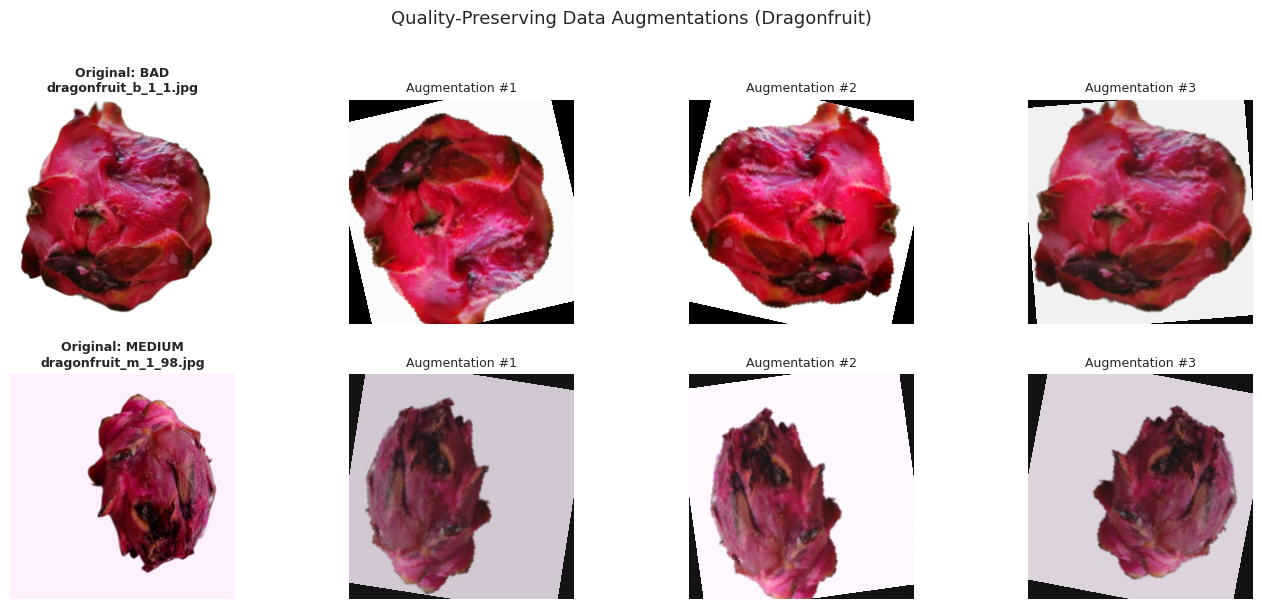

In [ ]:
# Visualize Data Augmentation Examples
def show_quality_augmentation_examples(dataset, aug_transforms, num_samples=2, num_augs=3):
    """Display raw quality images alongside multiple random quality augmentations."""
    fig, axes = plt.subplots(num_samples, num_augs + 1, figsize=(3.5 * (num_augs + 1), 3.0 * num_samples))
    sample_indices = np.linspace(0, len(dataset) - 1, num_samples, dtype=int)

    for row_idx, idx in enumerate(sample_indices):
        img_path, class_idx = dataset.samples[idx]
        class_name = dataset.classes[class_idx]
        img = Image.open(img_path).convert("RGB")

        # Raw original (resized)
        axes[row_idx, 0].imshow(img.resize((IMG_SIZE, IMG_SIZE)))
        axes[row_idx, 0].set_title(f"Original: {class_name.upper()}\n{Path(img_path).name}", fontsize=9, fontweight='bold')
        axes[row_idx, 0].axis('off')

        # Augmented variations
        for aug_idx in range(num_augs):
            aug_img = aug_transforms(img)
            if isinstance(aug_img, torch.Tensor):
                mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
                std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
                aug_disp = (aug_img * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
            else:
                aug_disp = aug_img
            axes[row_idx, aug_idx + 1].imshow(aug_disp)
            axes[row_idx, aug_idx + 1].set_title(f"Augmentation #{aug_idx+1}", fontsize=9)
            axes[row_idx, aug_idx + 1].axis('off')

    plt.suptitle(f"Quality-Preserving Data Augmentations ({SELECTED_FRUIT.capitalize()})", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(PLOTS_Q_DIR / f"{SELECTED_FRUIT}_augmentation_samples.png", dpi=300, bbox_inches="tight")
    plt.show()

show_quality_augmentation_examples(train_q_dataset, quality_train_transforms)


## 5. Training and Evaluation Infrastructure


In [ ]:
all_quality_results = {}

def train_quality_pytorch(model, train_loader, eval_loader, criterion, optimizer, scheduler=None, num_epochs=25, patience=5, model_name="model"):
    slug = model_name.lower().replace(" ", "_").replace("-", "_")
    checkpoint_path = MODELS_Q_DIR / f"best_{slug}.pth"
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [],
        'train_f1': [], 'val_f1': []
    }
    best_val_f1 = 0.0
    early_stop_cnt = 0
    start_t = time.time()
    use_amp = (device.type == 'cuda')
    scaler = torch.amp.GradScaler('cuda', enabled=use_amp)

    for epoch in range(num_epochs):
        ep_start = time.time()
        model.train()
        r_loss, r_corr, total_t = 0.0, 0, 0
        train_preds, train_targets = [], []
        train_pbar = tqdm(train_loader, desc=f"{model_name} [Epoch {epoch+1:02d}/{num_epochs:02d}] Train", leave=False)
        for inputs, labels in train_pbar:
            inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast(device_type=device.type, enabled=use_amp):
                outputs = model(inputs)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            _, preds = torch.max(outputs, 1)
            r_loss += loss.item() * inputs.size(0)
            r_corr += torch.sum(preds == labels.data)
            total_t += labels.size(0)

            train_preds.extend(preds.detach().cpu().numpy())
            train_targets.extend(labels.detach().cpu().numpy())

            train_pbar.set_postfix({'loss': f"{r_loss/total_t:.4f}", 'acc': f"{(r_corr.double()/total_t).item()*100:.2f}%"})

        if scheduler:
            scheduler.step()
        train_loss = r_loss / total_t if total_t > 0 else 0
        train_acc = (r_corr.double() / total_t).item() if total_t > 0 else 0
        train_f1 = f1_score(train_targets, train_preds, average='macro', zero_division=0)

        model.eval()
        vr_loss, vr_corr, total_v = 0.0, 0, 0
        val_preds, val_targets = [], []
        val_pbar = tqdm(eval_loader, desc=f"{model_name} [Epoch {epoch+1:02d}/{num_epochs:02d}] Eval", leave=False)
        with torch.no_grad():
            for inputs, labels in val_pbar:
                inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
                with torch.amp.autocast(device_type=device.type, enabled=use_amp):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)
                vr_loss += loss.item() * inputs.size(0)
                vr_corr += torch.sum(preds == labels.data)
                total_v += labels.size(0)

                val_preds.extend(preds.cpu().numpy())
                val_targets.extend(labels.cpu().numpy())

                val_pbar.set_postfix({'eval_loss': f"{vr_loss/total_v:.4f}", 'eval_acc': f"{(vr_corr.double()/total_v).item()*100:.2f}%"})

        val_loss = vr_loss / total_v if total_v > 0 else 0
        val_acc = (vr_corr.double() / total_v).item() if total_v > 0 else 0
        val_f1 = f1_score(val_targets, val_preds, average='macro', zero_division=0)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['train_f1'].append(train_f1)
        history['val_f1'].append(val_f1)

        ep_time = time.time() - ep_start
        print(f"Epoch {epoch+1:02d}/{num_epochs:02d} [{ep_time:.1f}s] | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc*100:.2f}% F1: {train_f1:.4f} | "
              f"Test Loss: {val_loss:.4f} Acc: {val_acc*100:.2f}% F1: {val_f1:.4f}")

        # Checkpointing based on evaluation Macro F1 score
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            early_stop_cnt = 0
            torch.save(model.state_dict(), checkpoint_path)
        else:
            early_stop_cnt += 1
            if early_stop_cnt >= patience:
                print(f"Early stopping triggered at epoch {epoch+1} (Best Test Macro F1: {best_val_f1:.4f}).")
                break

    time_elapsed = time.time() - start_t
    print(f"Completed in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s. Best evaluation Macro F1: {best_val_f1:.4f}")

    # 3-Panel Learning Curves Plot: Loss, Accuracy, and Macro F1
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    epochs = range(1, len(history['train_loss']) + 1)

    # 1. Loss Curve
    axes[0].plot(epochs, history['train_loss'], 'o-', label='Train Loss', color='royalblue')
    axes[0].plot(epochs, history['val_loss'], 's-', label='Test Loss', color='crimson')
    axes[0].set_title(f"{model_name}: Loss vs Epochs")
    axes[0].set_xlabel("Epochs")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    # 2. Accuracy Curve
    axes[1].plot(epochs, [a * 100 for a in history['train_acc']], 'o-', label='Train Acc', color='royalblue')
    axes[1].plot(epochs, [a * 100 for a in history['val_acc']], 's-', label='Test Acc', color='crimson')
    axes[1].set_title(f"{model_name}: Accuracy vs Epochs")
    axes[1].set_xlabel("Epochs")
    axes[1].set_ylabel("Accuracy (%)")
    axes[1].legend()

    # 3. Macro F1 Curve
    axes[2].plot(epochs, history['train_f1'], 'o-', label='Train Macro F1', color='royalblue')
    axes[2].plot(epochs, history['val_f1'], 's-', label='Test Macro F1', color='crimson')
    axes[2].set_title(f"{model_name}: Macro F1 vs Epochs")
    axes[2].set_xlabel("Epochs")
    axes[2].set_ylabel("Macro F1-Score")
    axes[2].set_ylim([0, 1.05])
    axes[2].legend()

    plt.tight_layout()
    plt.savefig(PLOTS_Q_DIR / f"{slug}_learning_curves.png", dpi=300)
    plt.show()

    if checkpoint_path.exists():
        model.load_state_dict(torch.load(checkpoint_path))
    return model, history


In [ ]:
def plot_quality_prediction_samples(image_paths, y_true, y_pred, y_prob, class_names, model_name, output_plots_dir, max_per_class=4):
    """Generate and save 2 plots per model: Correct Predictions and Misclassified Samples with perfectly centered multi-color labels."""
    from matplotlib.offsetbox import AnchoredOffsetbox, TextArea, HPacker, VPacker
    slug = model_name.lower().replace(" ", "_").replace("-", "_")
    output_plots_dir = Path(output_plots_dir)
    n_classes = len(class_names)

    # 1. Correct Predictions Plot (4 per class)
    fig_corr, axes_corr = plt.subplots(n_classes, max_per_class, figsize=(max_per_class * 3.2, n_classes * 3.2))
    if n_classes == 1:
        axes_corr = np.expand_dims(axes_corr, 0)
    if max_per_class == 1:
        axes_corr = np.expand_dims(axes_corr, 1)

    for c_idx, c_name in enumerate(class_names):
        corr_indices = np.where((y_true == c_idx) & (y_pred == c_idx))[0]
        for col_idx in range(max_per_class):
            ax = axes_corr[c_idx, col_idx]
            ax.axis('off')
            if col_idx < len(corr_indices):
                idx = corr_indices[col_idx]
                img_p = image_paths[idx]
                conf = y_prob[idx][y_pred[idx]] * 100
                img = Image.open(img_p).convert("RGB")
                ax.imshow(img.resize((224, 224)))
                fname = Path(img_p).name

                t_fname = TextArea(fname, textprops=dict(color='#111111', fontweight='bold', size=8))
                t_true = TextArea(c_name, textprops=dict(color='#2e7d32', fontweight='bold', size=8))
                t_sep = TextArea(' | ', textprops=dict(color='#555555', size=8))
                t_pred = TextArea(f"{c_name} ({conf:.1f}%)", textprops=dict(color='#2e7d32', fontweight='bold', size=8))

                line2_box = HPacker(children=[t_true, t_sep, t_pred], align='center', pad=0, sep=0)
                both_lines = VPacker(children=[t_fname, line2_box], align='center', pad=0, sep=4)

                anchored_box = AnchoredOffsetbox(
                    loc='lower center',
                    child=both_lines,
                    pad=0.,
                    frameon=False,
                    bbox_to_anchor=(0.5, 1.02),
                    bbox_transform=ax.transAxes,
                    borderpad=0.
                )
                ax.add_artist(anchored_box)
            else:
                ax.text(0.5, 0.5, "-", ha='center', va='center', color='gray')

    fig_corr.suptitle(f"{model_name} - Correct Quality Predictions ({SELECTED_FRUIT.capitalize()})", fontsize=14, y=0.995)
    plt.subplots_adjust(top=0.93, hspace=0.38, wspace=0.15)
    fig_corr.savefig(output_plots_dir / f"{slug}_correct_predictions.png", dpi=300, bbox_inches="tight")
    plt.show()

    # 2. Misclassified / Wrong Predictions Plot (up to 4 per class)
    fig_err, axes_err = plt.subplots(n_classes, max_per_class, figsize=(max_per_class * 3.2, n_classes * 3.2))
    if n_classes == 1:
        axes_err = np.expand_dims(axes_err, 0)
    if max_per_class == 1:
        axes_err = np.expand_dims(axes_err, 1)

    for c_idx, c_name in enumerate(class_names):
        err_indices = np.where((y_true == c_idx) & (y_pred != c_idx))[0]
        for col_idx in range(max_per_class):
            ax = axes_err[c_idx, col_idx]
            ax.axis('off')
            if col_idx < len(err_indices):
                idx = err_indices[col_idx]
                img_p = image_paths[idx]
                pred_c_name = class_names[y_pred[idx]]
                conf = y_prob[idx][y_pred[idx]] * 100
                img = Image.open(img_p).convert("RGB")
                ax.imshow(img.resize((224, 224)))
                fname = Path(img_p).name

                t_fname = TextArea(fname, textprops=dict(color='#111111', fontweight='bold', size=8))
                t_true = TextArea(c_name, textprops=dict(color='#2e7d32', fontweight='bold', size=8))
                t_sep = TextArea(' | ', textprops=dict(color='#555555', size=8))
                t_pred = TextArea(f"{pred_c_name} ({conf:.1f}%)", textprops=dict(color='#d32f2f', fontweight='bold', size=8))

                line2_box = HPacker(children=[t_true, t_sep, t_pred], align='center', pad=0, sep=0)
                both_lines = VPacker(children=[t_fname, line2_box], align='center', pad=0, sep=4)

                anchored_box = AnchoredOffsetbox(
                    loc='lower center',
                    child=both_lines,
                    pad=0.,
                    frameon=False,
                    bbox_to_anchor=(0.5, 1.02),
                    bbox_transform=ax.transAxes,
                    borderpad=0.
                )
                ax.add_artist(anchored_box)
            else:
                if col_idx == 0 and len(err_indices) == 0:
                    ax.text(0.5, 0.5, f"No Errors for {c_name}\n(100% Accuracy)", ha='center', va='center', color='#2e7d32', fontsize=8, fontweight="bold")
                else:
                    ax.text(0.5, 0.5, "-", ha='center', va='center', color='gray')

    fig_err.suptitle(f"{model_name} - Misclassified Quality Predictions ({SELECTED_FRUIT.capitalize()})", fontsize=14, y=0.995)
    plt.subplots_adjust(top=0.93, hspace=0.38, wspace=0.15)
    fig_err.savefig(output_plots_dir / f"{slug}_wrong_predictions.png", dpi=300, bbox_inches="tight")
    plt.show()

def evaluate_and_record_quality(y_true, y_pred, y_prob, model_name, class_names, results_dict, image_paths=None):
    slug = model_name.lower().replace(" ", "_").replace("-", "_")

    print(f"\n=======================================================")
    print(f"      {model_name.upper()} QUALITY EVALUATION ({SELECTED_FRUIT.upper()})")
    print(f"=======================================================")
    rep_text = classification_report(y_true, y_pred, target_names=class_names, digits=4)
    print(rep_text)

    with open(REPORTS_Q_DIR / f"{slug}_classification_report.txt", "w") as f:
        f.write(rep_text)
    pd.DataFrame(classification_report(y_true, y_pred, target_names=class_names, output_dict=True)).transpose().to_csv(REPORTS_Q_DIR / f"{slug}_classification_report.csv")

    acc = np.mean(y_true == y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    weighted_f1 = f1_score(y_true, y_pred, average='weighted')

    np.savez_compressed(
        REPORTS_Q_DIR / f"{slug}_predictions.npz",
        y_true=y_true,
        y_pred=y_pred,
        y_prob=y_prob
    )

    results_dict[model_name] = {
        'Fruit': SELECTED_FRUIT,
        'Accuracy': acc,
        'Macro F1': macro_f1,
        'Weighted F1': weighted_f1
    }

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Greens', xticklabels=class_names, yticklabels=class_names, ax=axes[0])
    axes[0].set_title(f"{model_name} - Confusion Matrix ({SELECTED_FRUIT.capitalize()})")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("True")

    n_classes = len(class_names)
    y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))
    fpr, tpr, roc_auc = dict(), dict(), dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    fpr["macro"], tpr["macro"], _ = roc_curve(y_true_bin.ravel(), y_prob.ravel())
    roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

    colors = ['green', 'goldenrod', 'crimson']
    for i, color in zip(range(n_classes), colors):
        axes[1].plot(fpr[i], tpr[i], color=color, lw=1.5, label=f'{class_names[i].upper()} (AUC = {roc_auc[i]:.3f})')
    axes[1].plot([0, 1], [0, 1], 'k--', lw=1.2)
    axes[1].set_title(f"{model_name} - ROC Curves")
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].legend(loc='lower right')

    plt.tight_layout()
    plt.savefig(PLOTS_Q_DIR / f"{slug}_confusion_matrix_and_roc.png", dpi=300)
    plt.show()

    # 3. Additional Visualizations: Correct and Wrong Predictions
    if image_paths is not None and len(image_paths) == len(y_true):
        plot_quality_prediction_samples(image_paths, y_true, y_pred, y_prob, class_names, model_name, PLOTS_Q_DIR, max_per_class=4)


In [ ]:
def evaluate_pytorch_model(model, loader):
    """Run inference across evaluation dataset and collect labels, predictions, and softmax probabilities."""
    model.eval()
    all_p, all_l, all_prob = [], [], []
    use_amp = (device.type == 'cuda')
    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc="Inference", leave=False):
            inputs = inputs.to(device, non_blocking=True)
            with torch.amp.autocast(device_type=device.type, enabled=use_amp):
                outputs = model(inputs)
                probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            all_prob.append(probs.cpu().numpy())
            all_p.append(preds.cpu().numpy())
            all_l.append(labels.numpy())
    return np.concatenate(all_l), np.concatenate(all_p), np.concatenate(all_prob)

def cleanup_gpu_memory(model_var_names):
    """Reclaim PyTorch and CUDA memory allocations."""
    for name in model_var_names:
        if name in globals():
            del globals()[name]
    torch.cuda.empty_cache()
    gc.collect()

def plot_yolo_learning_curves(run_dir, model_name, output_plots_dir):
    """Extract and plot training/validation metrics for YOLO from results.csv."""
    slug = model_name.lower().replace(" ", "_").replace("-", "_")
    csv_path = Path(run_dir) / "results.csv"
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        df.columns = [c.strip() for c in df.columns]
        epochs = df['epoch'] if 'epoch' in df.columns else range(1, len(df) + 1)

        has_train_loss = 'train/loss' in df.columns
        has_val_loss = 'val/loss' in df.columns
        has_acc = 'metrics/accuracy_top1' in df.columns

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        if has_train_loss and has_val_loss:
            axes[0].plot(epochs, df['train/loss'], 'o-', label='Train Loss', color='royalblue')
            axes[0].plot(epochs, df['val/loss'], 's-', label='Test Loss', color='crimson')
            axes[0].set_title(f"{model_name}: Loss vs Epochs")
            axes[0].set_xlabel("Epochs")
            axes[0].set_ylabel("Loss")
            axes[0].legend()

        if has_acc:
            axes[1].plot(epochs, df['metrics/accuracy_top1'] * 100, 's-', label='Test Top-1 Acc', color='crimson')
            axes[1].set_title(f"{model_name}: Top-1 Accuracy vs Epochs")
            axes[1].set_xlabel("Epochs")
            axes[1].set_ylabel("Accuracy (%)")
            axes[1].legend()

        plt.tight_layout()
        plt.savefig(Path(output_plots_dir) / f"{slug}_learning_curves.png", dpi=300)
        plt.show()


---
## Model 1: Custom CNN
A 4-stage convolutional neural network baseline with batch normalization, LeakyReLU non-linearities, spatial max-pooling, and dropout regularization fine-tuned for quality assessment.


Custom CNN [Epoch 01/25] Train:   0%|          | 0/21 [00:00<?, ?it/s]

Custom CNN [Epoch 01/25] Eval:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 01/25 [45.9s] | Train Loss: 0.6755 Acc: 71.34% F1: 0.7052 | Test Loss: 0.5158 Acc: 69.76% F1: 0.6385


Custom CNN [Epoch 02/25] Train:   0%|          | 0/21 [00:00<?, ?it/s]

Custom CNN [Epoch 02/25] Eval:   0%|          | 0/6 [00:00<?, ?it/s]

...

Custom CNN [Epoch 08/25] Eval:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 08/25 [17.5s] | Train Loss: 0.2104 Acc: 90.32% F1: 0.9027 | Test Loss: 0.2506 Acc: 82.93% F1: 0.8208


Custom CNN [Epoch 09/25] Train:   0%|          | 0/21 [00:00<?, ?it/s]

Custom CNN [Epoch 09/25] Eval:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 09/25 [17.9s] | Train Loss: 0.1776 Acc: 92.57% F1: 0.9252 | Test Loss: 0.1675 Acc: 90.12% F1: 0.8992
Early stopping triggered at epoch 9 (Best Test Macro F1: 0.9969).
Completed in 3m 6s. Best evaluation Macro F1: 0.9969


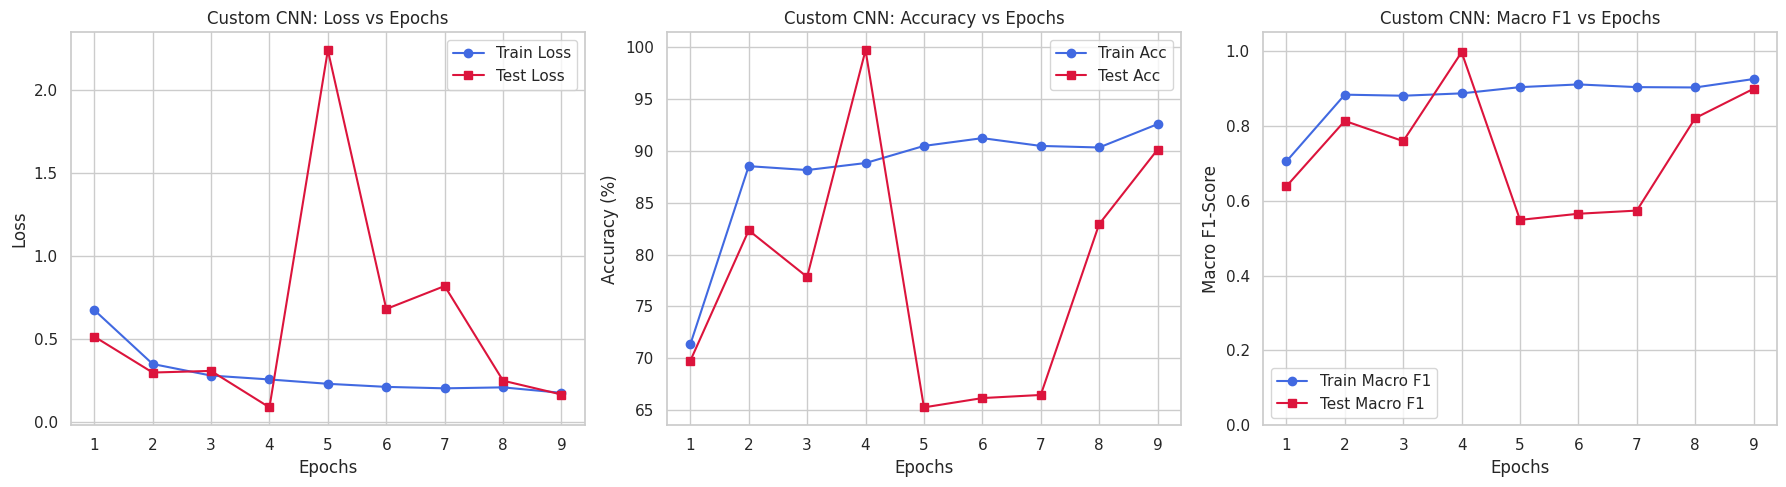

Inference:   0%|          | 0/6 [00:00<?, ?it/s]


      CUSTOM CNN QUALITY EVALUATION (DRAGONFRUIT)
              precision    recall  f1-score   support

         bad     1.0000    1.0000    1.0000       116
        good     1.0000    0.9911    0.9955       112
      medium     0.9907    1.0000    0.9953       106

    accuracy                         0.9970       334
   macro avg     0.9969    0.9970    0.9969       334
weighted avg     0.9970    0.9970    0.9970       334



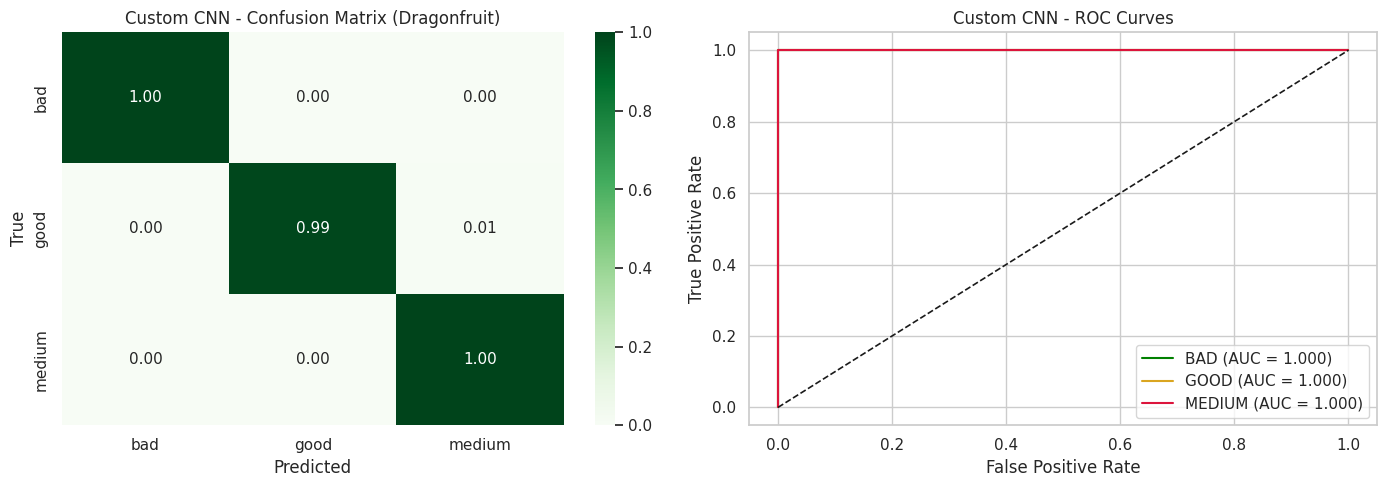

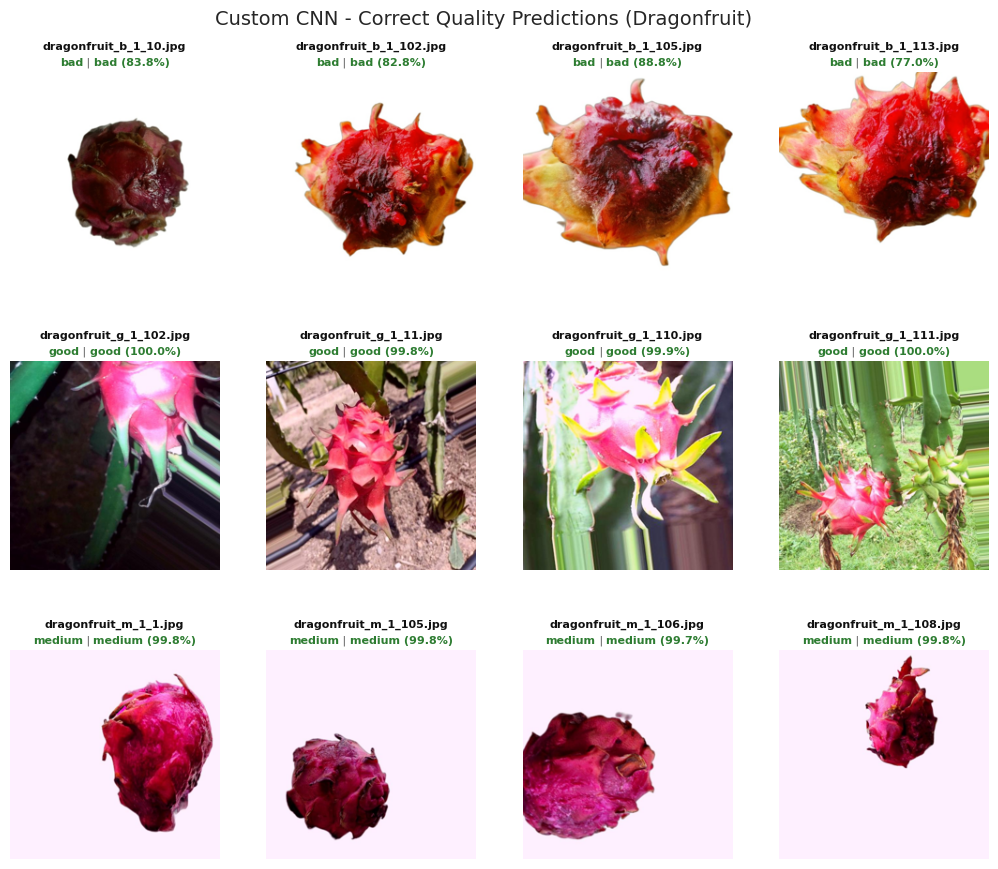

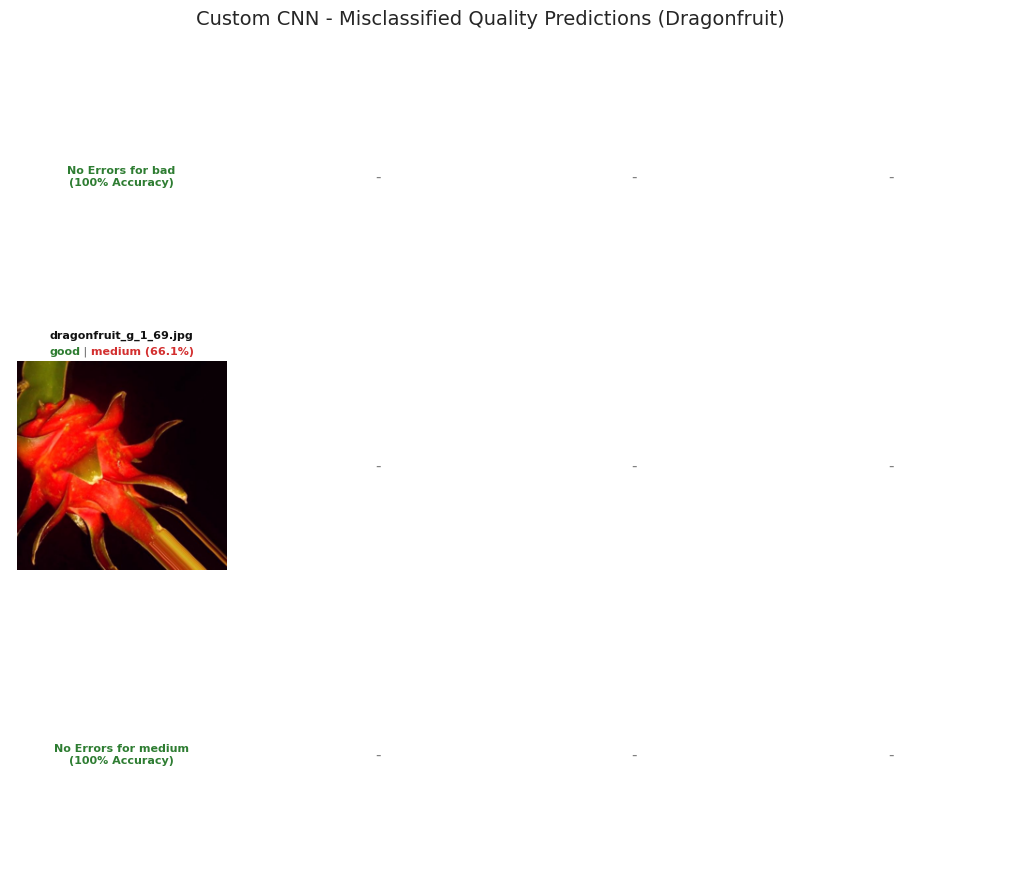

In [ ]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes=3, dropout_rate=0.3):
        super(CustomCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.1, inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.1, inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.1, inplace=True),
            nn.MaxPool2d(2, 2)
        )
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, 64),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.global_pool(self.features(x)))

quality_cnn = CustomCNN(num_classes=NUM_QUALITY_CLASSES, dropout_rate=0.3).to(device)
criterion_q = nn.CrossEntropyLoss()
opt_q_cnn = optim.AdamW(quality_cnn.parameters(), lr=1e-3, weight_decay=1e-4)
sched_q_cnn = optim.lr_scheduler.CosineAnnealingLR(opt_q_cnn, T_max=25)

quality_cnn, q_cnn_hist = train_quality_pytorch(
    quality_cnn, train_q_loader, test_q_loader, criterion_q, opt_q_cnn,
    scheduler=sched_q_cnn, num_epochs=25, patience=5, model_name="Custom CNN"
)

y_true_q_cnn, y_pred_q_cnn, y_prob_q_cnn = evaluate_pytorch_model(quality_cnn, test_q_loader)
evaluate_and_record_quality(y_true_q_cnn, y_pred_q_cnn, y_prob_q_cnn, "Custom CNN", quality_class_names, all_quality_results, image_paths=test_q_image_paths)

cleanup_gpu_memory(['quality_cnn', 'opt_q_cnn', 'sched_q_cnn', 'criterion_q'])


---
## Model 2: MobileNetV3-Large
Pretrained lightweight architecture fine-tuned for quality assessment.


Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 121MB/s] 


MobileNetV3-Large [Epoch 01/25] Train:   0%|          | 0/21 [00:00<?, ?it/s]

MobileNetV3-Large [Epoch 01/25] Eval:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 01/25 [129.0s] | Train Loss: 0.5240 Acc: 78.09% F1: 0.7711 | Test Loss: 0.4881 Acc: 74.25% F1: 0.7419


...

MobileNetV3-Large [Epoch 14/25] Eval:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 14/25 [17.6s] | Train Loss: 0.0026 Acc: 100.00% F1: 1.0000 | Test Loss: 0.0055 Acc: 99.70% F1: 0.9970


MobileNetV3-Large [Epoch 15/25] Train:   0%|          | 0/21 [00:00<?, ?it/s]

MobileNetV3-Large [Epoch 15/25] Eval:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 15/25 [16.8s] | Train Loss: 0.0033 Acc: 99.92% F1: 0.9992 | Test Loss: 0.0078 Acc: 99.70% F1: 0.9970
Early stopping triggered at epoch 15 (Best Test Macro F1: 1.0000).
Completed in 6m 8s. Best evaluation Macro F1: 1.0000


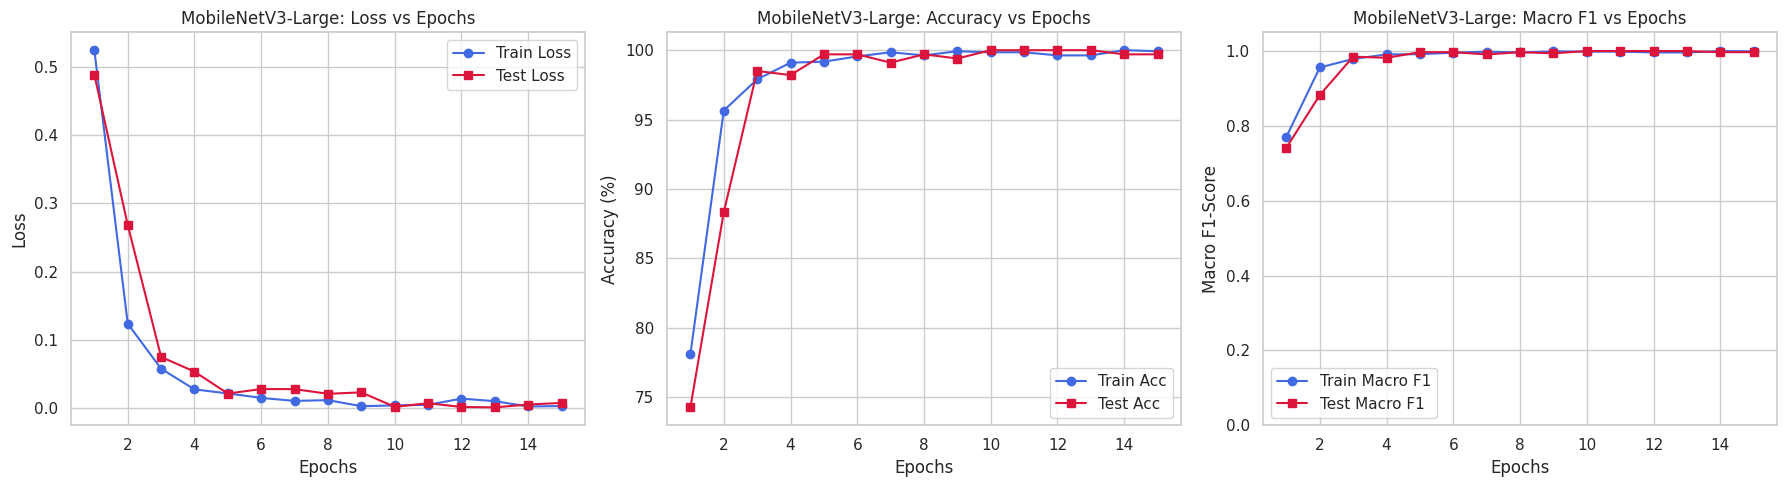

Inference:   0%|          | 0/6 [00:00<?, ?it/s]


      MOBILENETV3-LARGE QUALITY EVALUATION (DRAGONFRUIT)
              precision    recall  f1-score   support

         bad     1.0000    1.0000    1.0000       116
        good     1.0000    1.0000    1.0000       112
      medium     1.0000    1.0000    1.0000       106

    accuracy                         1.0000       334
   macro avg     1.0000    1.0000    1.0000       334
weighted avg     1.0000    1.0000    1.0000       334



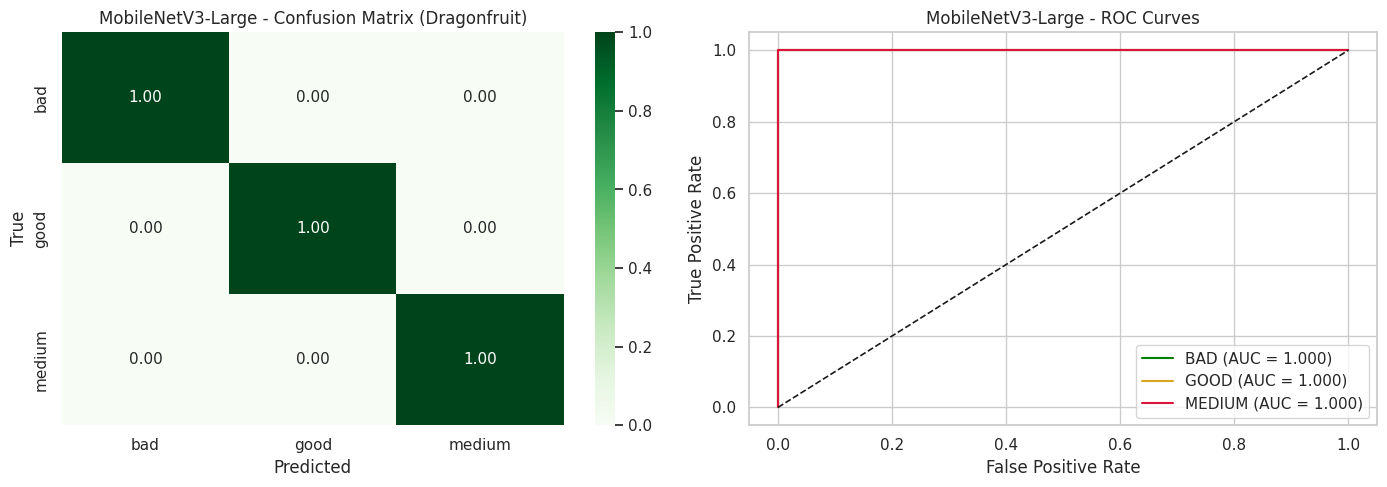

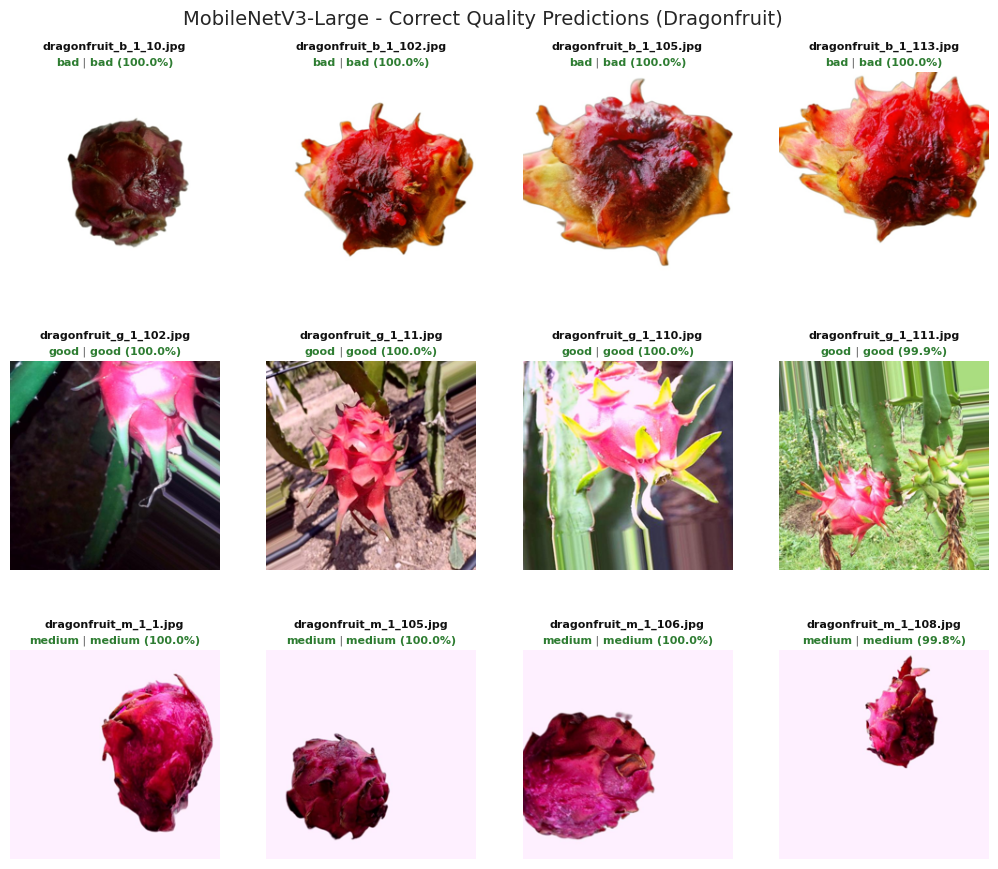

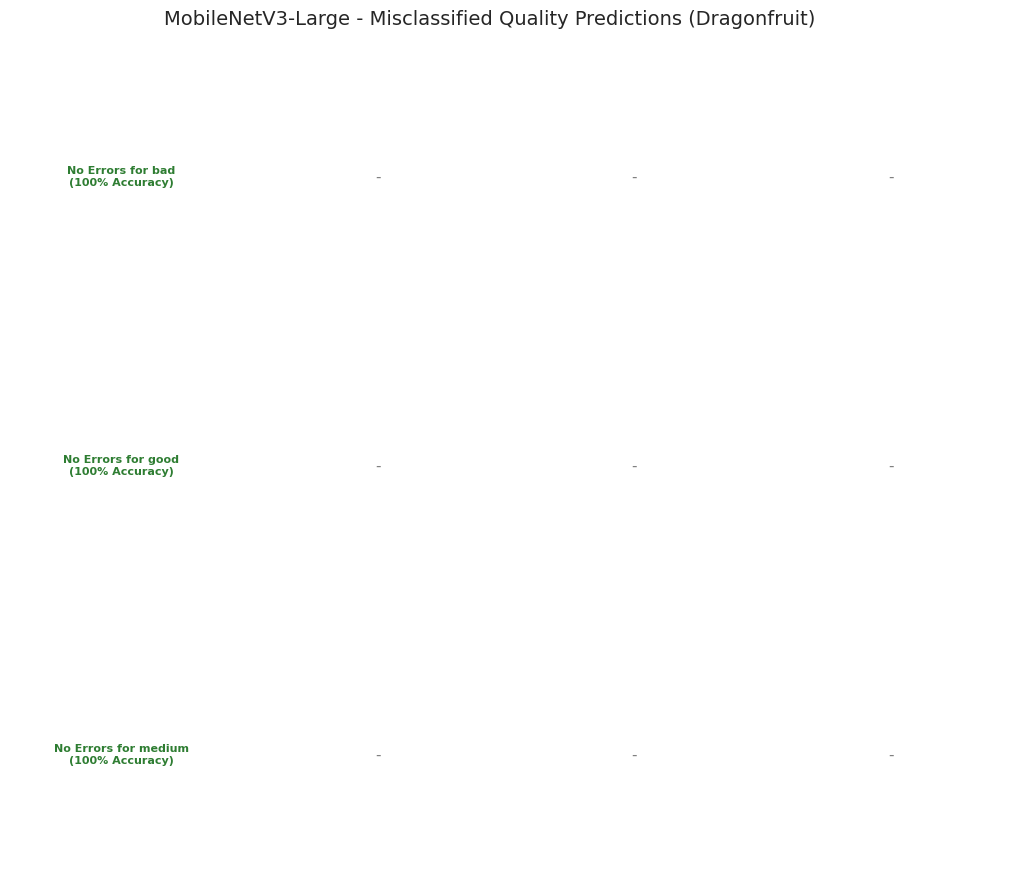

In [ ]:
def build_quality_mobilenet(num_classes=3):
    model = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.DEFAULT)
    in_f = model.classifier[3].in_features
    model.classifier[3] = nn.Sequential(nn.Dropout(p=0.3), nn.Linear(in_f, num_classes))
    return model

mb_q_model = build_quality_mobilenet(num_classes=NUM_QUALITY_CLASSES).to(device)
criterion_mb_q = nn.CrossEntropyLoss()
opt_mb_q = optim.AdamW(mb_q_model.parameters(), lr=2e-4, weight_decay=1e-4)
sched_mb_q = optim.lr_scheduler.CosineAnnealingLR(opt_mb_q, T_max=25)

mb_q_model, mb_q_hist = train_quality_pytorch(
    mb_q_model, train_q_loader, test_q_loader, criterion_mb_q, opt_mb_q,
    scheduler=sched_mb_q, num_epochs=25, patience=5, model_name="MobileNetV3-Large"
)

y_true_mb_q, y_pred_mb_q, y_prob_mb_q = evaluate_pytorch_model(mb_q_model, test_q_loader)
evaluate_and_record_quality(y_true_mb_q, y_pred_mb_q, y_prob_mb_q, "MobileNetV3-Large", quality_class_names, all_quality_results, image_paths=test_q_image_paths)

cleanup_gpu_memory(['mb_q_model', 'opt_mb_q', 'sched_mb_q', 'criterion_mb_q'])


---
## Model 3: YOLO26 Classifier
Ultralytics official YOLO26 classification architecture (`yolo26n-cls.pt`) for quality grading. All model weights and runs are saved in OUTPUT_QUALITY_DIR.


Ultralytics 8.4.155 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data_quality, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo26_dragonfruit_cls, nbs=64, nms=None, opset=Non

YOLO Quality Inference:   0%|          | 0/3 [00:00<?, ?it/s]


      YOLO26N-CLS QUALITY EVALUATION (DRAGONFRUIT)
              precision    recall  f1-score   support

         bad     1.0000    1.0000    1.0000       116
        good     1.0000    1.0000    1.0000       112
      medium     1.0000    1.0000    1.0000       106

    accuracy                         1.0000       334
   macro avg     1.0000    1.0000    1.0000       334
weighted avg     1.0000    1.0000    1.0000       334



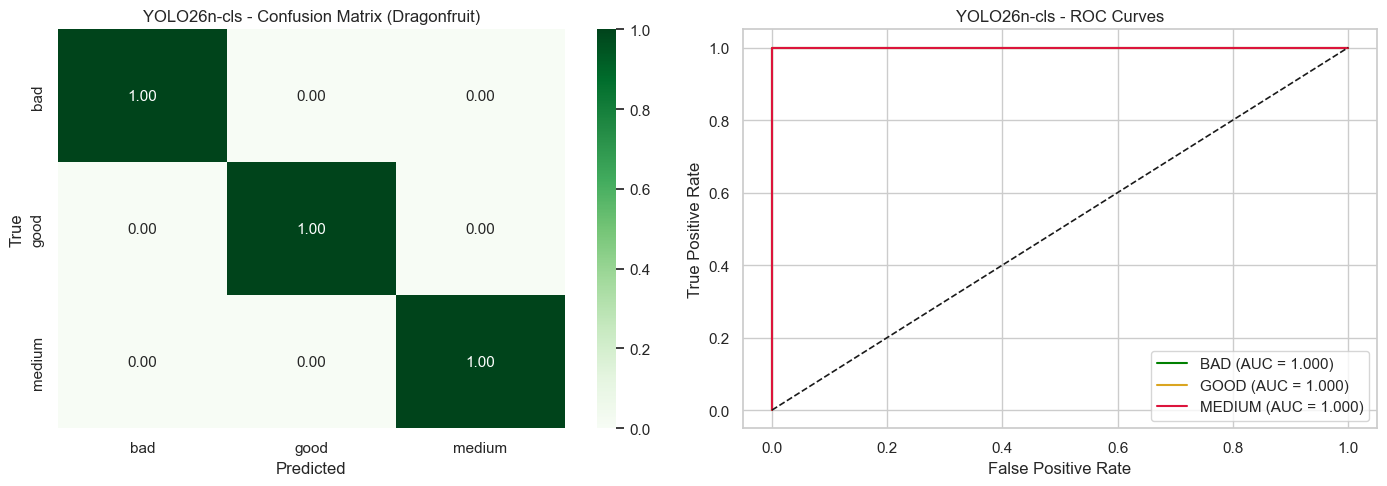

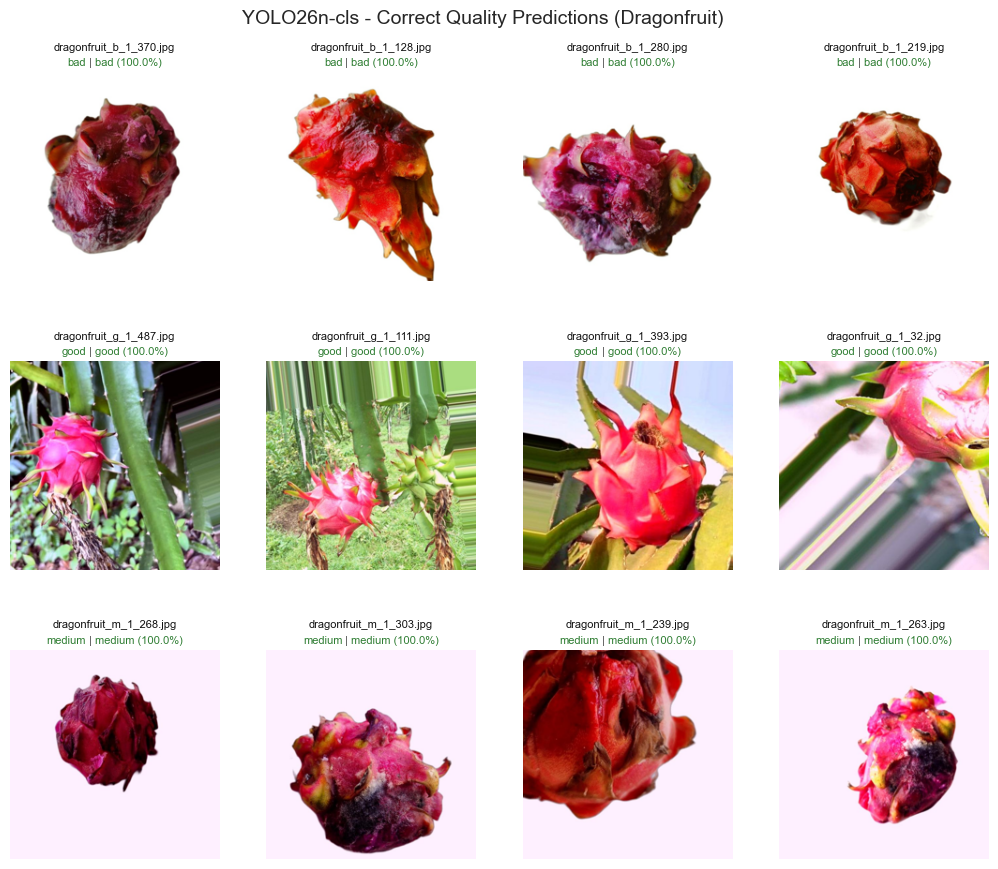

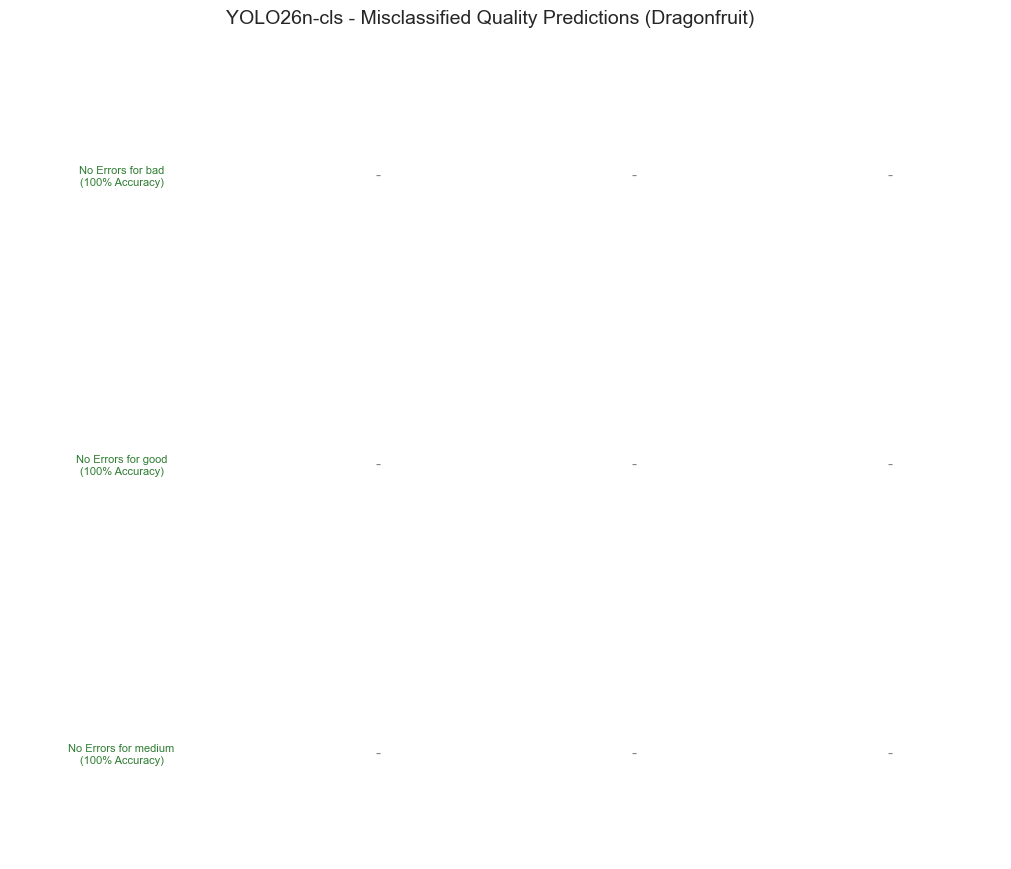

In [ ]:
yolo26_q_model = YOLO("yolo26n-cls.pt")

yolo26_q_results = yolo26_q_model.train(
    data=str(Path("data_quality").resolve()),
    epochs=25,
    imgsz=224,
    batch=BATCH_SIZE,
    device=0 if torch.cuda.is_available() else 'cpu',
    seed=SEED,
    workers=0,
    project=str((OUTPUT_QUALITY_DIR / "runs_yolo").resolve()),
    name=f"yolo26_{SELECTED_FRUIT}_cls",
    exist_ok=True
)

best_q_pt_candidates = [
    Path(getattr(yolo26_q_results, 'save_dir', '')) / 'weights' / 'best.pt',
    Path(getattr(getattr(yolo26_q_model, 'trainer', None), 'save_dir', '')) / 'weights' / 'best.pt',
    OUTPUT_QUALITY_DIR / "runs_yolo" / f"yolo26_{SELECTED_FRUIT}_cls" / "weights" / "best.pt",
    Path(f"runs/classify/yolo26_{SELECTED_FRUIT}_cls/weights/best.pt"),
    Path(f"runs/yolo26_{SELECTED_FRUIT}_cls/weights/best.pt")
]

found_q_weights = None
for cand in best_q_pt_candidates:
    if cand and cand.exists():
        found_q_weights = cand
        break

if not found_q_weights:
    for search_root in [OUTPUT_QUALITY_DIR, Path("runs")]:
        matches = list(Path(search_root).glob("**/best.pt"))
        if matches:
            found_q_weights = matches[0]
            break

target_q_weights = MODELS_Q_DIR / f"best_yolo26_{SELECTED_FRUIT}_cls.pt"
if found_q_weights and found_q_weights.exists():
    shutil.copy2(found_q_weights, target_q_weights)
    print(f"YOLO26 Quality model weights successfully saved to: {target_q_weights}")
else:
    print(f"Warning: Could not locate YOLO26 Quality best.pt. Checked: {best_q_pt_candidates}")

def evaluate_yolo_quality_predictions(model, test_dir, class_names):
    test_path = Path(test_dir)
    labels, preds, probs, paths = [], [], [], []
    c2i = {name: i for i, name in enumerate(class_names)}

    for cname in tqdm(class_names, desc="YOLO Quality Inference", leave=False):
        cfolder = test_path / cname
        if not cfolder.exists():
            continue
        imgs = [f for f in cfolder.iterdir() if f.suffix.lower() in VALID_EXTENSIONS]
        for img_p in imgs:
            res = model(str(img_p), verbose=False)[0]
            p_arr = res.probs.data.cpu().numpy()
            labels.append(c2i[cname])
            preds.append(int(np.argmax(p_arr)))
            probs.append(p_arr)
            paths.append(str(img_p))

    return np.array(labels), np.array(preds), np.array(probs), paths

y_true_qyolo26, y_pred_qyolo26, y_prob_qyolo26, qyolo_test_paths = evaluate_yolo_quality_predictions(yolo26_q_model, "data_quality/test", quality_class_names)
evaluate_and_record_quality(y_true_qyolo26, y_pred_qyolo26, y_prob_qyolo26, "YOLO26n-cls", quality_class_names, all_quality_results, image_paths=qyolo_test_paths)

cleanup_gpu_memory(['yolo26_q_model', 'yolo26_q_results'])


---
## Model 4: EfficientNet-B0
Compound-scaled convolutional architecture for balanced depth, width, and resolution scaling in quality grading.


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 133MB/s] 


EfficientNet-B0 [Epoch 01/25] Train:   0%|          | 0/21 [00:00<?, ?it/s]

EfficientNet-B0 [Epoch 01/25] Eval:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 01/25 [131.3s] | Train Loss: 0.6414 Acc: 76.59% F1: 0.7642 | Test Loss: 0.2338 Acc: 91.92% F1: 0.9175


...

EfficientNet-B0 [Epoch 08/25] Eval:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 08/25 [19.3s] | Train Loss: 0.0072 Acc: 99.85% F1: 0.9985 | Test Loss: 0.0008 Acc: 100.00% F1: 1.0000


EfficientNet-B0 [Epoch 09/25] Train:   0%|          | 0/21 [00:00<?, ?it/s]

EfficientNet-B0 [Epoch 09/25] Eval:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 09/25 [18.6s] | Train Loss: 0.0072 Acc: 99.85% F1: 0.9985 | Test Loss: 0.0006 Acc: 100.00% F1: 1.0000
Early stopping triggered at epoch 9 (Best Test Macro F1: 1.0000).
Completed in 4m 43s. Best evaluation Macro F1: 1.0000


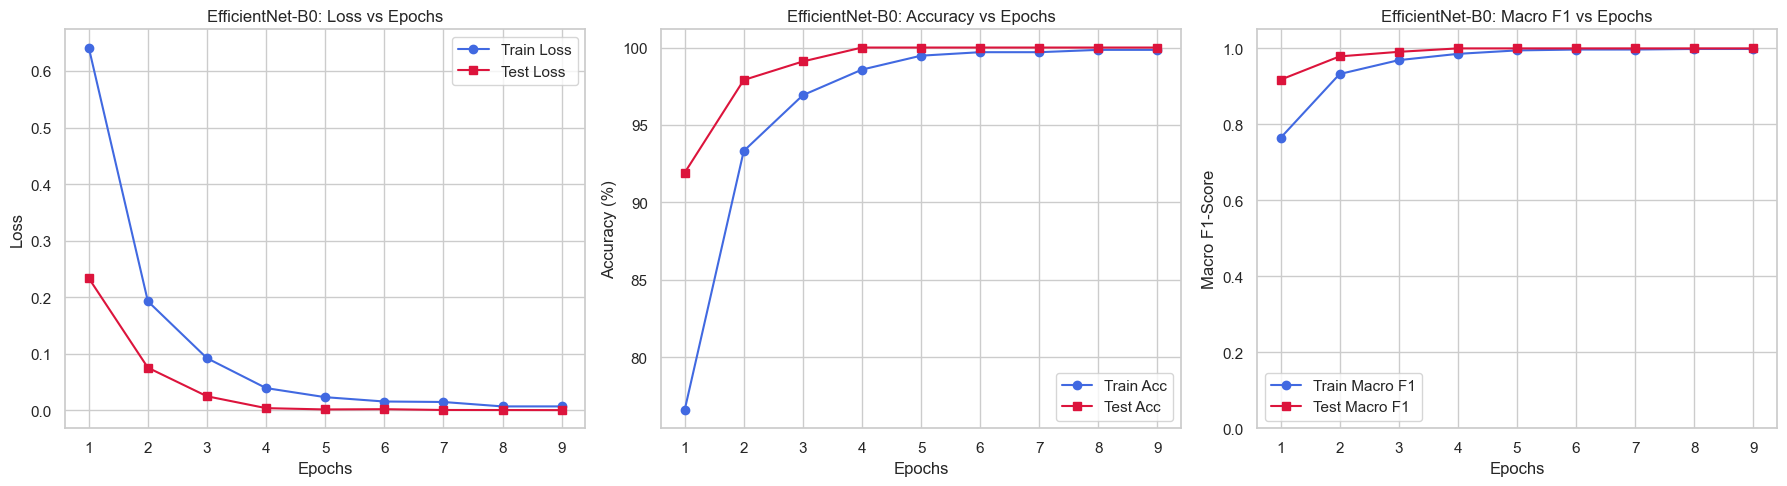

Inference:   0%|          | 0/6 [00:00<?, ?it/s]


      EFFICIENTNET-B0 QUALITY EVALUATION (DRAGONFRUIT)
              precision    recall  f1-score   support

         bad     1.0000    1.0000    1.0000       116
        good     1.0000    1.0000    1.0000       112
      medium     1.0000    1.0000    1.0000       106

    accuracy                         1.0000       334
   macro avg     1.0000    1.0000    1.0000       334
weighted avg     1.0000    1.0000    1.0000       334



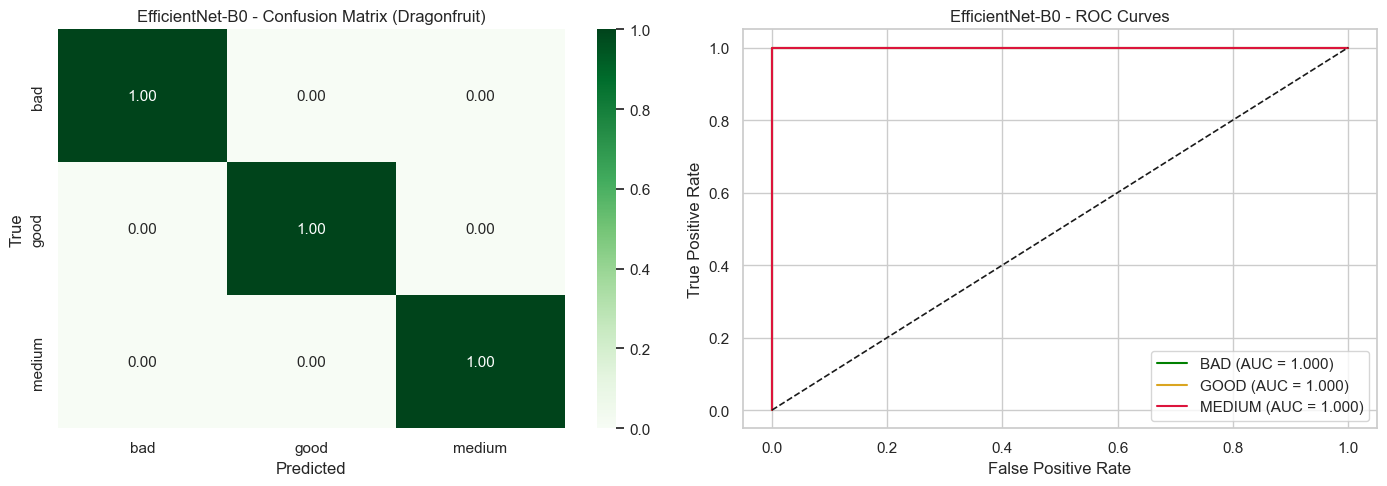

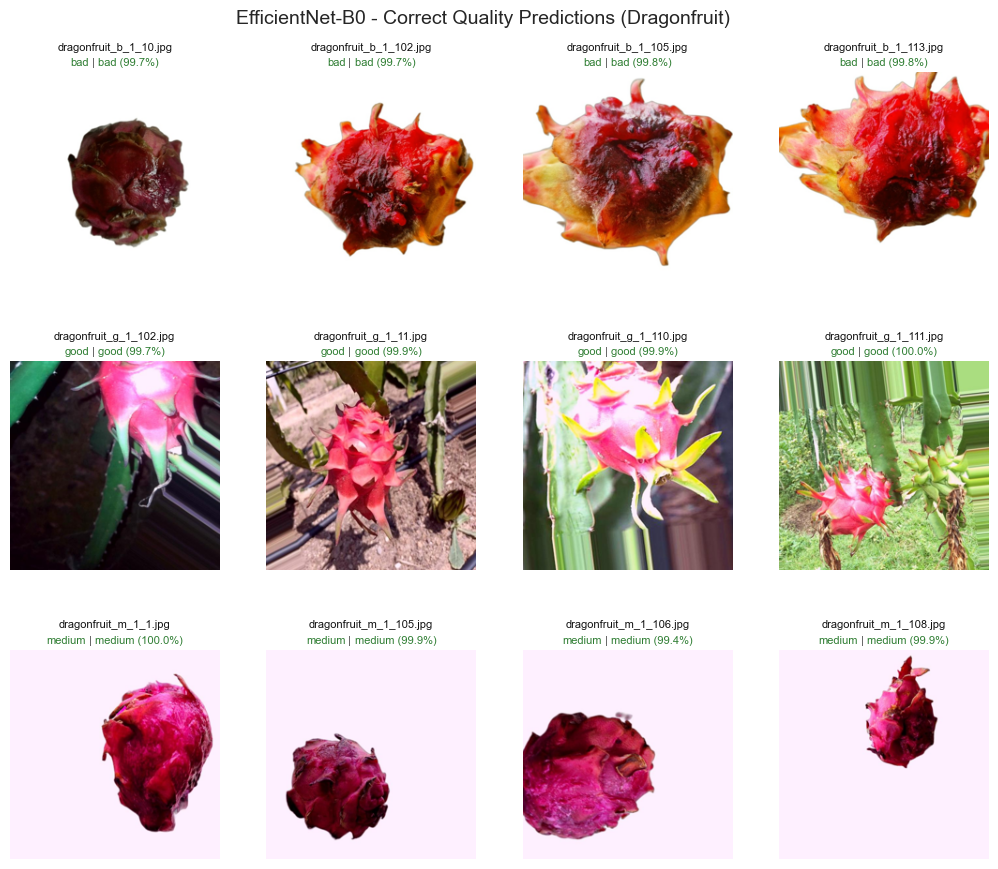

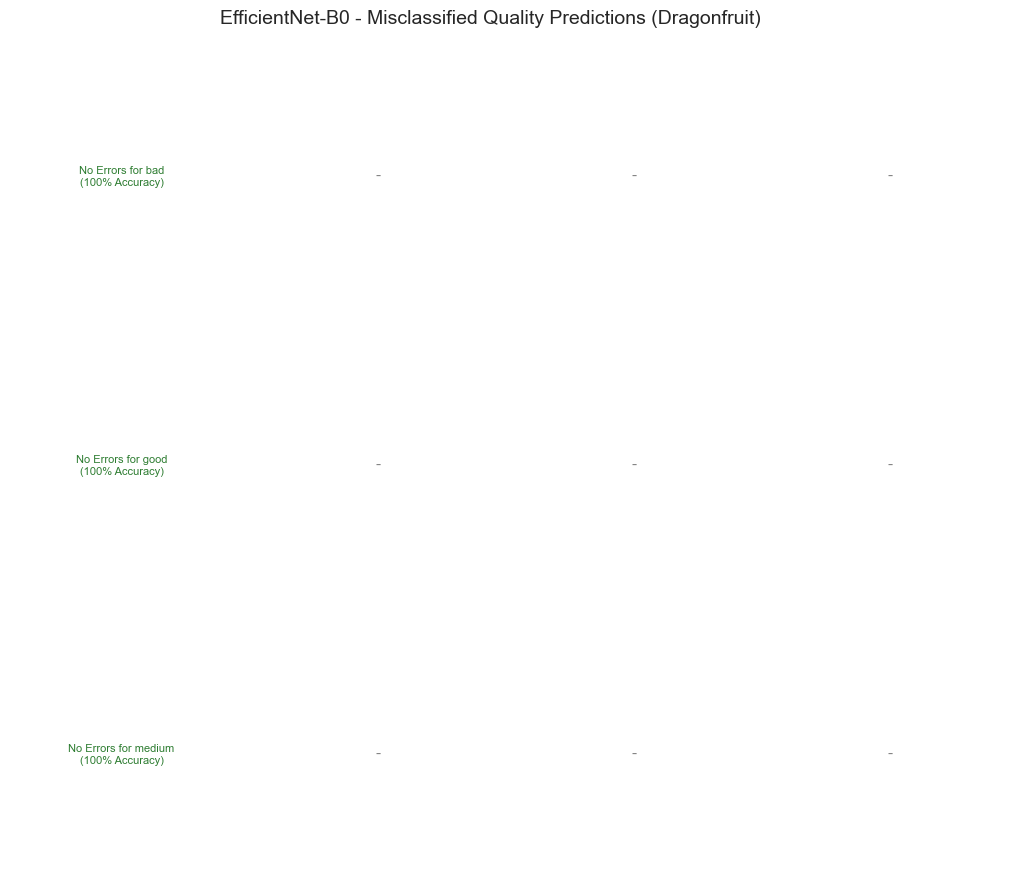

In [ ]:
def build_quality_efficientnet(num_classes=3):
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
    in_f = model.classifier[1].in_features
    model.classifier[1] = nn.Sequential(nn.Dropout(p=0.3), nn.Linear(in_f, num_classes))
    return model

eff_q_model = build_quality_efficientnet(num_classes=NUM_QUALITY_CLASSES).to(device)
criterion_eff_q = nn.CrossEntropyLoss()
opt_eff_q = optim.AdamW(eff_q_model.parameters(), lr=2e-4, weight_decay=1e-4)
sched_eff_q = optim.lr_scheduler.CosineAnnealingLR(opt_eff_q, T_max=25)

eff_q_model, eff_q_hist = train_quality_pytorch(
    eff_q_model, train_q_loader, test_q_loader, criterion_eff_q, opt_eff_q,
    scheduler=sched_eff_q, num_epochs=25, patience=5, model_name="EfficientNet-B0"
)

y_true_eff_q, y_pred_eff_q, y_prob_eff_q = evaluate_pytorch_model(eff_q_model, test_q_loader)
evaluate_and_record_quality(y_true_eff_q, y_pred_eff_q, y_prob_eff_q, "EfficientNet-B0", quality_class_names, all_quality_results, image_paths=test_q_image_paths)

cleanup_gpu_memory(['eff_q_model', 'opt_eff_q', 'sched_eff_q', 'criterion_eff_q'])


---
## Model 5: ResNet-50
50-layer deep residual network for fine-grained surface defect discrimination.


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 156MB/s]


ResNet-50 [Epoch 01/25] Train:   0%|          | 0/21 [00:00<?, ?it/s]

ResNet-50 [Epoch 01/25] Eval:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 01/25 [44.0s] | Train Loss: 0.7330 Acc: 73.22% F1: 0.7112 | Test Loss: 0.3898 Acc: 85.33% F1: 0.8425


...

ResNet-50 [Epoch 07/25] Eval:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 07/25 [21.4s] | Train Loss: 0.0412 Acc: 98.80% F1: 0.9879 | Test Loss: 0.0038 Acc: 100.00% F1: 1.0000


ResNet-50 [Epoch 08/25] Train:   0%|          | 0/21 [00:00<?, ?it/s]

ResNet-50 [Epoch 08/25] Eval:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 08/25 [20.6s] | Train Loss: 0.0255 Acc: 99.32% F1: 0.9932 | Test Loss: 0.0048 Acc: 100.00% F1: 1.0000
Early stopping triggered at epoch 8 (Best Test Macro F1: 1.0000).
Completed in 3m 12s. Best evaluation Macro F1: 1.0000


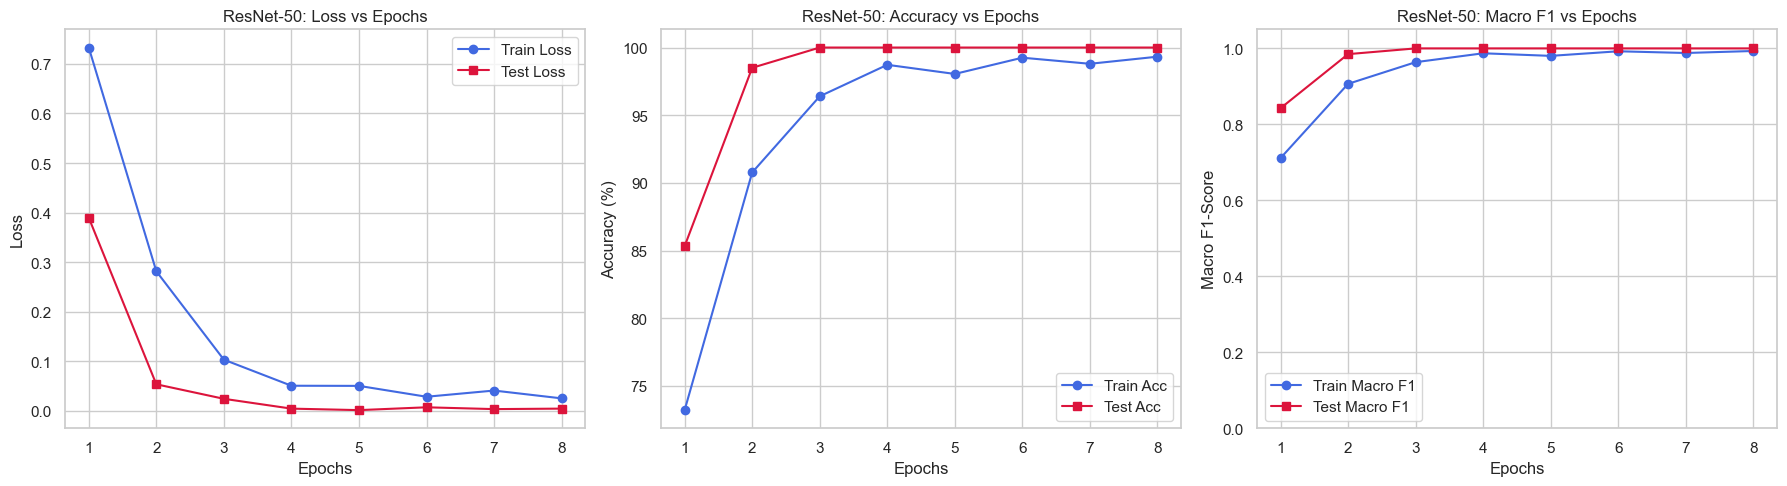

Inference:   0%|          | 0/6 [00:00<?, ?it/s]


      RESNET-50 QUALITY EVALUATION (DRAGONFRUIT)
              precision    recall  f1-score   support

         bad     1.0000    1.0000    1.0000       116
        good     1.0000    1.0000    1.0000       112
      medium     1.0000    1.0000    1.0000       106

    accuracy                         1.0000       334
   macro avg     1.0000    1.0000    1.0000       334
weighted avg     1.0000    1.0000    1.0000       334



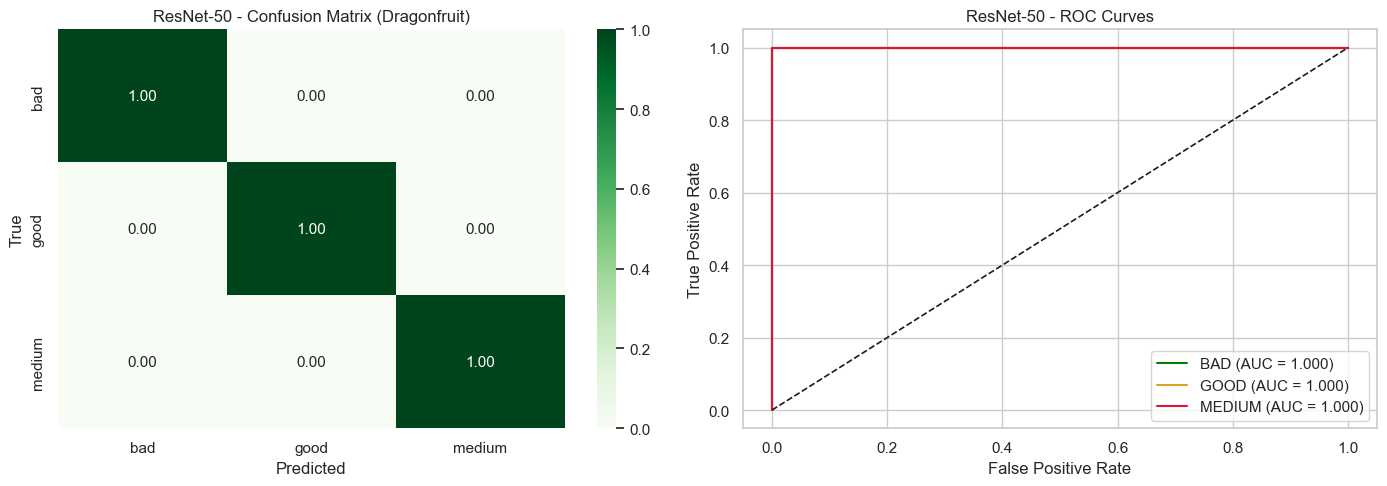

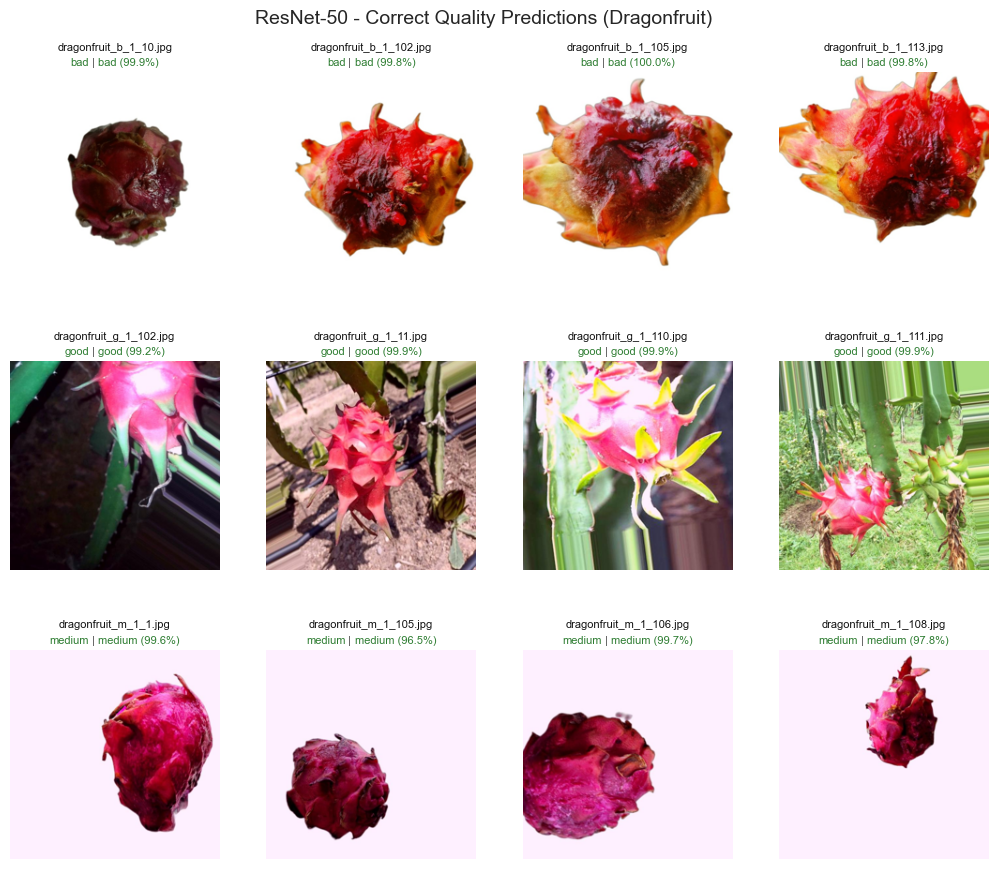

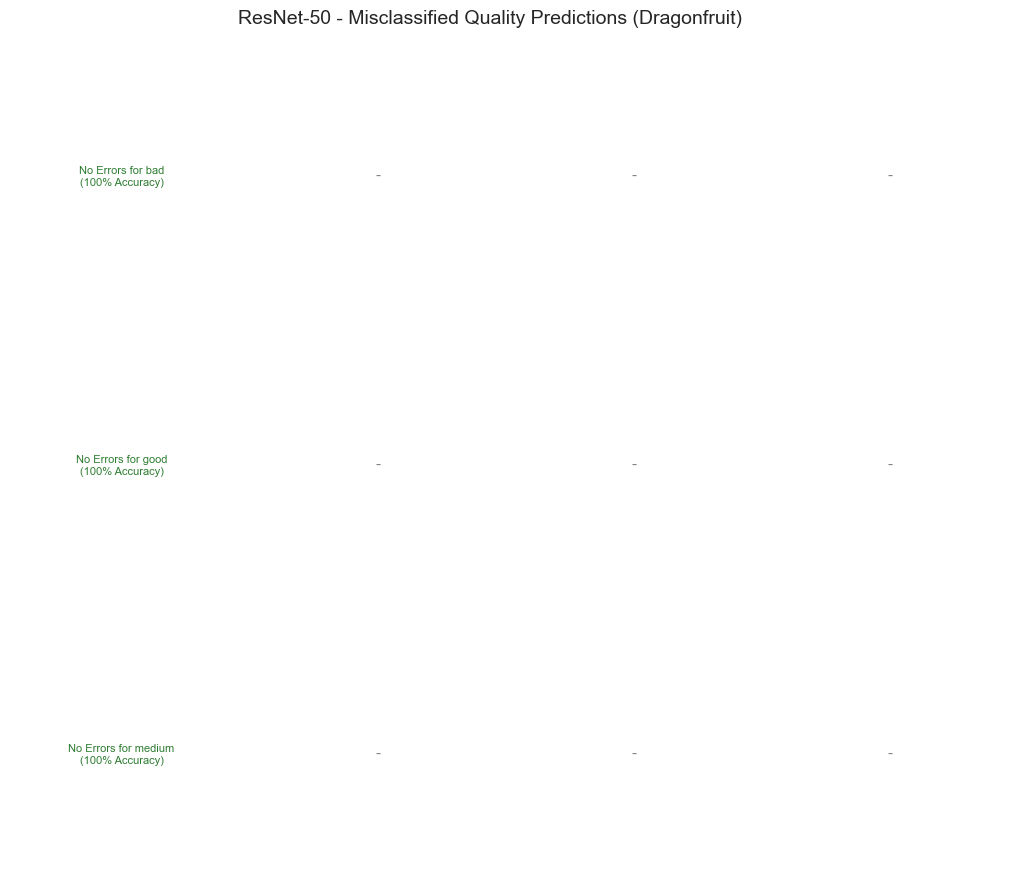

In [ ]:
def build_quality_resnet50(num_classes=3):
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    in_f = model.fc.in_features
    model.fc = nn.Sequential(nn.Dropout(p=0.3), nn.Linear(in_f, num_classes))
    return model

resnet_q_model = build_quality_resnet50(num_classes=NUM_QUALITY_CLASSES).to(device)
criterion_res_q = nn.CrossEntropyLoss()
opt_res_q = optim.AdamW(resnet_q_model.parameters(), lr=1e-4, weight_decay=1e-4)
sched_res_q = optim.lr_scheduler.CosineAnnealingLR(opt_res_q, T_max=25)

resnet_q_model, resnet_q_hist = train_quality_pytorch(
    resnet_q_model, train_q_loader, test_q_loader, criterion_res_q, opt_res_q,
    scheduler=sched_res_q, num_epochs=25, patience=5, model_name="ResNet-50"
)

y_true_res_q, y_pred_res_q, y_prob_res_q = evaluate_pytorch_model(resnet_q_model, test_q_loader)
evaluate_and_record_quality(y_true_res_q, y_pred_res_q, y_prob_res_q, "ResNet-50", quality_class_names, all_quality_results, image_paths=test_q_image_paths)

cleanup_gpu_memory(['resnet_q_model', 'opt_res_q', 'sched_res_q', 'criterion_res_q'])


---
## 7. Comparative Benchmark and Results Summary
Consolidated comparative analysis across all five evaluated architectures for quality grading on the unseen test set.


In [ ]:
summary_q_rows = []
for model_name, metrics in all_quality_results.items():
    summary_q_rows.append({
        "Model Architecture": model_name,
        "Fruit Evaluated": metrics['Fruit'],
        "Accuracy (%)": f"{metrics['Accuracy'] * 100:.2f}%",
        "Macro F1": f"{metrics['Macro F1']:.4f}",
        "Weighted F1": f"{metrics['Weighted F1']:.4f}"
    })

df_q_benchmark = pd.DataFrame(summary_q_rows)
display(df_q_benchmark)

q_csv_path = OUTPUT_QUALITY_DIR / "final_quality_benchmark_summary.csv"
df_q_benchmark.to_csv(q_csv_path, index=False)


,Model Architecture,Fruit Evaluated,Accuracy (%),Macro F1,Weighted F1
0,Custom CNN,dragonfruit,99.70%,0.9969,0.9970
1,MobileNetV3-Large,dragonfruit,100.00%,1.0000,1.0000
2,YOLO26n-cls,dragonfruit,100.00%,1.0000,1.0000
3,EfficientNet-B0,dragonfruit,100.00%,1.0000,1.0000
4,ResNet-50,dragonfruit,100.00%,1.0000,1.0000


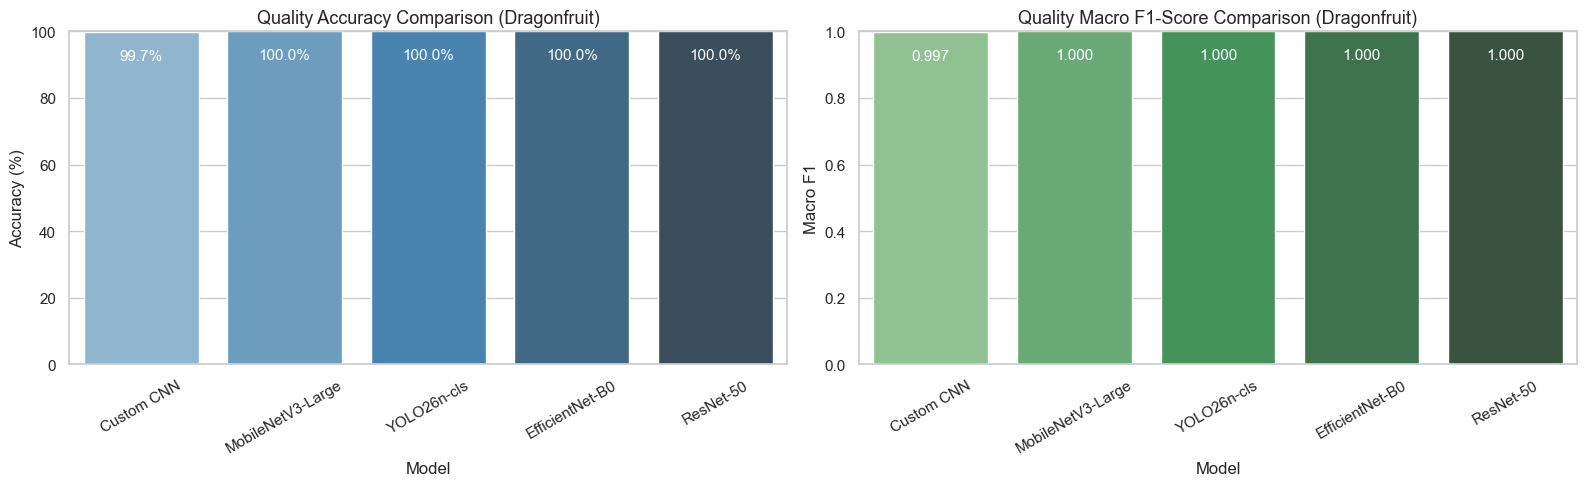

In [ ]:
if not df_q_benchmark.empty:
    chart_q_data = pd.DataFrame([
        {
            "Model": name,
            "Accuracy (%)": metrics['Accuracy'] * 100,
            "Macro F1": metrics['Macro F1']
        }
        for name, metrics in all_quality_results.items()
    ])

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    sns.barplot(data=chart_q_data, x="Model", y="Accuracy (%)", hue="Model", palette="Blues_d", legend=False, ax=axes[0])
    axes[0].set_title(f"Quality Accuracy Comparison ({SELECTED_FRUIT.capitalize()})", fontsize=13)
    axes[0].set_ylim([0, 100])
    axes[0].tick_params(axis='x', rotation=30)
    for p in axes[0].patches:
        axes[0].annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() - 7),
                         ha='center', va='center', color='white', fontweight='bold')

    sns.barplot(data=chart_q_data, x="Model", y="Macro F1", hue="Model", palette="Greens_d", legend=False, ax=axes[1])
    axes[1].set_title(f"Quality Macro F1-Score Comparison ({SELECTED_FRUIT.capitalize()})", fontsize=13)
    axes[1].set_ylim([0, 1.0])
    axes[1].tick_params(axis='x', rotation=30)
    for p in axes[1].patches:
        axes[1].annotate(f"{p.get_height():.3f}", (p.get_x() + p.get_width() / 2., p.get_height() - 0.07),
                         ha='center', va='center', color='white', fontweight='bold')

    plt.tight_layout()
    plt.savefig(PLOTS_Q_DIR / "final_quality_benchmark_comparison.png", dpi=300)
    plt.show()


## 8. Export Outputs


In [ ]:
# Compress outputs directory with dynamic fruit name
zip_filename = f"fruit_quality_outputs_{SELECTED_FRUIT}.zip"
shutil.make_archive(f"fruit_quality_outputs_{SELECTED_FRUIT}", 'zip', OUTPUT_QUALITY_DIR)
print(f"Outputs compressed to: {zip_filename}")

if 'google.colab' in sys.modules:
    try:
        from google.colab import files
        files.download(zip_filename)
    except Exception as e:
        print(f"Colab download skipped/error: {e}")


Outputs compressed to: fruit_quality_outputs_dragonfruit.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>